In [12]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 512
LATENT_DIM = 2
EPOCHS = 10000
LR = 1e-4


# Data

In [14]:
def get_swiss_roll(samples=512):
    t = 1.5 * 3.14159 * (1 + 2 * torch.rand(samples, 1))
    x = t * torch.cos(t)
    y = t * torch.sin(t)
    data = torch.cat([x, y], dim=1)
    data += 0.5 * torch.randn_like(data)
    return data


# Models

In [15]:
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(LATENT_DIM, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, 2)
        )
    def forward(self, z):
        return self.net(z)


In [16]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, 128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, 128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, 128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, 1)
        )
    def forward(self, x):
        return self.net(x)


# Training

In [17]:
gen = Generator().to(device)
disc = Discriminator().to(device)

g_opt = torch.optim.Adam(gen.parameters(), lr=LR, betas=(0.5, 0.999))
d_opt = torch.optim.Adam(disc.parameters(), lr=LR, betas=(0.5, 0.999))


In [18]:
for epoch in range(EPOCHS):
    x_real = get_swiss_roll(BATCH_SIZE).to(device)

    # Update Discriminator (Hinge Loss)
    d_opt.zero_grad(set_to_none=True)

    d_real_out = disc(x_real)
    loss_real = torch.mean(F.relu(1.0 - d_real_out))

    z = torch.randn(BATCH_SIZE, LATENT_DIM, device=device)
    x_fake = gen(z).detach()
    d_fake_out = disc(x_fake)
    loss_fake = torch.mean(F.relu(1.0 + d_fake_out))

    d_loss = loss_real + loss_fake
    d_loss.backward()
    d_opt.step()

    # Update Generator
    g_opt.zero_grad(set_to_none=True)
    z = torch.randn(BATCH_SIZE, LATENT_DIM, device=device)
    x_fake = gen(z)
    g_loss = torch.mean(F.relu(1.0 - disc(x_fake)))
    g_loss.backward()
    g_opt.step()

    if epoch % 100 == 0:
        print(f"Epoch {epoch:4d} | D Loss: {d_loss.item():.4f} | G Loss: {g_loss.item():.4f}")


Epoch    0 | D Loss: 2.0274 | G Loss: 0.9613
Epoch  100 | D Loss: 0.4977 | G Loss: 1.7335
Epoch  200 | D Loss: 0.1677 | G Loss: 2.0630
Epoch  300 | D Loss: 0.2275 | G Loss: 2.2441
Epoch  400 | D Loss: 0.1701 | G Loss: 2.3715
Epoch  500 | D Loss: 0.8009 | G Loss: 1.9937
Epoch  600 | D Loss: 0.9666 | G Loss: 2.1315
Epoch  700 | D Loss: 0.8513 | G Loss: 1.9661
Epoch  800 | D Loss: 1.0972 | G Loss: 1.9389
Epoch  900 | D Loss: 1.2240 | G Loss: 1.8471
Epoch 1000 | D Loss: 1.4262 | G Loss: 2.0968
Epoch 1100 | D Loss: 1.6138 | G Loss: 1.4586
Epoch 1200 | D Loss: 1.7525 | G Loss: 1.4973
Epoch 1300 | D Loss: 1.8472 | G Loss: 1.4358
Epoch 1400 | D Loss: 1.9414 | G Loss: 1.3882
Epoch 1500 | D Loss: 1.9827 | G Loss: 1.1338
Epoch 1600 | D Loss: 1.9379 | G Loss: 1.4172
Epoch 1700 | D Loss: 1.9136 | G Loss: 1.0444
Epoch 1800 | D Loss: 1.9053 | G Loss: 1.3538
Epoch 1900 | D Loss: 1.8867 | G Loss: 1.2818
Epoch 2000 | D Loss: 1.8956 | G Loss: 1.1925
Epoch 2100 | D Loss: 1.8543 | G Loss: 1.1145
Epoch 2200

# Results

In [19]:
gen.eval()
with torch.no_grad():
    z = torch.randn(5000, LATENT_DIM, device=device)
    fake_points = gen(z).cpu()
    real_points = get_swiss_roll(5000).cpu()


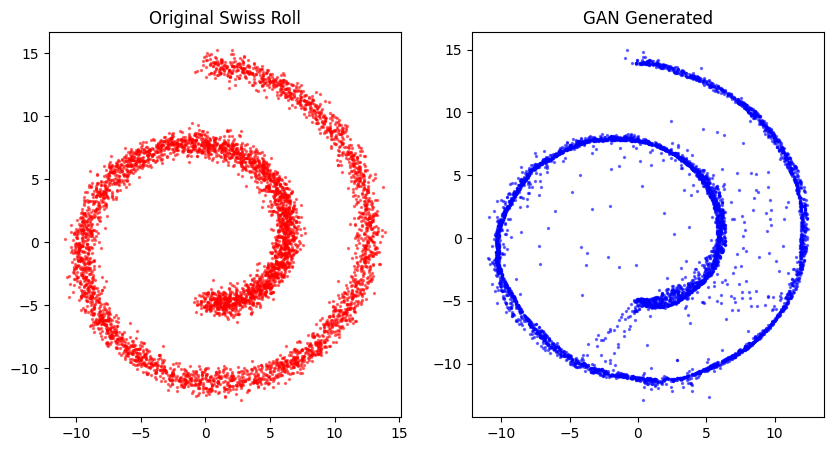

In [20]:
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.scatter(real_points[:, 0], real_points[:, 1], s=2, c='red', alpha=0.5)
plt.title("Original Swiss Roll")
plt.subplot(1, 2, 2)
plt.scatter(fake_points[:, 0], fake_points[:, 1], s=2, c='blue', alpha=0.5)
plt.title("GAN Generated")
plt.show()